In [2]:
import duckdb, matplotlib.pyplot as plt
from pathlib import Path
con = duckdb.connect("../data/processed/lending.duckdb", read_only=True)
FIG = Path("../reports/figures"); FIG.mkdir(parents=True, exist_ok=True)
def q(sql):
    return con.execute(sql).df()

Default rate by vintage:

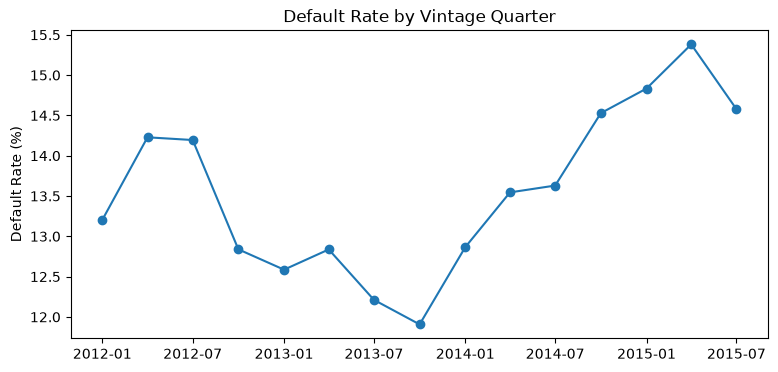

In [2]:
d = q("""SELECT date_trunc('quarter', issue_date) AS vintage,
            avg(default_flag)*100 AS default_pct, count(*) AS n
        FROM cohort GROUP BY 1 ORDER BY 1""")
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(d["vintage"], d["default_pct"], marker="o")
ax.set_ylabel("Default Rate (%)"); ax.set_title("Default Rate by Vintage Quarter")
fig.savefig(FIG/"default_rate_by_vintage.png", dpi=150, bbox_inches="tight")

Drifts from ~11.9% to ~15.4%. Random CV would mix regimes. Out-of-time split.

Default rate by grade and sub-grade:

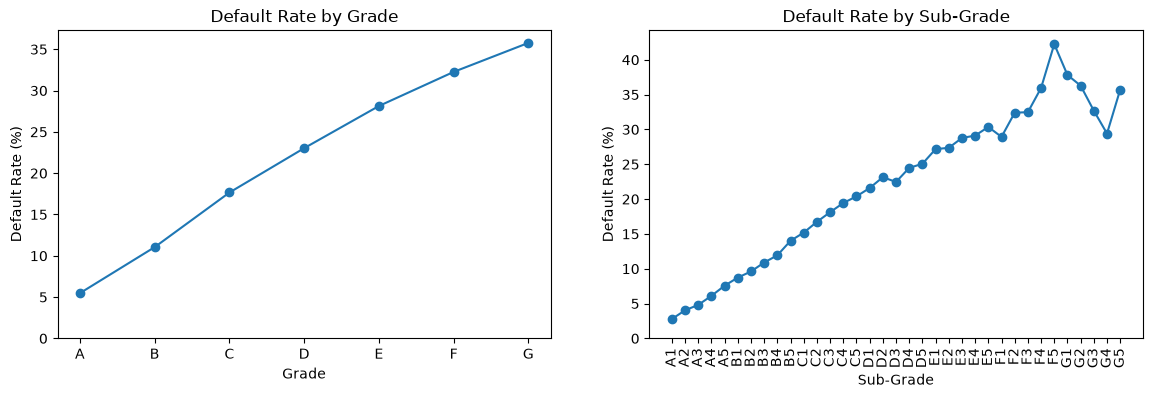

In [7]:
d_grade = q("""SELECT grade,
            avg(default_flag)*100 AS default_pct, count(*) AS n
        FROM cohort GROUP BY 1 ORDER BY 1""")
d_subgrade = q("""SELECT sub_grade,
            avg(default_flag)*100 AS default_pct, count(*) AS n
        FROM cohort GROUP BY 1 ORDER BY 1""")
fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(14, 4))

ax1.plot(d_grade["grade"], d_grade["default_pct"], marker="o")
ax1.set_ylim(0)
ax1.set_ylabel("Default Rate (%)"); ax1.set_xlabel("Grade"); ax1.set_title("Default Rate by Grade")

ax2.plot(d_subgrade["sub_grade"], d_subgrade["default_pct"], marker="o")
ax2.set_ylim(0)
ax2.set_ylabel("Default Rate (%)"); ax2.set_xlabel("Sub-Grade"); ax2.set_title("Default Rate by Sub-Grade")
ax2.tick_params(axis='x', rotation=90)

fig.savefig(FIG/"default_rate_by_grade_sub_grade.png", dpi=150, bbox_inches="tight")

Left: Monotone increase from 5.48% (A) to 35.77% (G) visualises LendingClub's grading model in rank-ordering risk.
Right: Monotone increase through 36.0% (F4); the apparent non-monotonicity in F5-G5 reflects thin cells (n≤258) in a 36 month cohort where riskier grades were mostly issued at 60-month terms.

Default rate by purpose

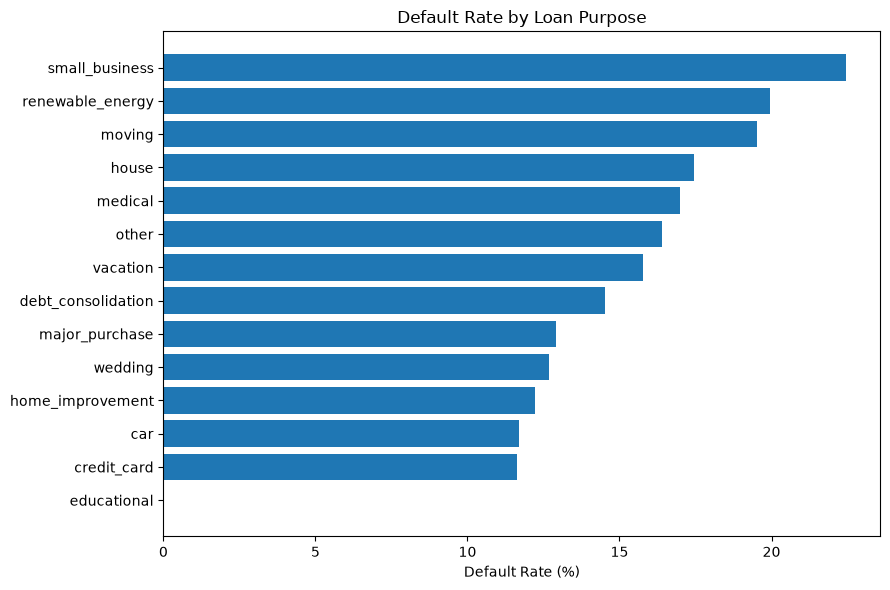

In [4]:
d_purpose = q("""SELECT purpose,
            avg(default_flag)*100 AS default_pct, count(*) AS n
        FROM cohort GROUP BY 1 ORDER BY 2 DESC""")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(d_purpose["purpose"], d_purpose["default_pct"])
ax.invert_yaxis()
ax.set_xlabel("Default Rate (%)"); ax.set_title("Default Rate by Loan Purpose")
fig.tight_layout()
fig.savefig(FIG/"default_rate_by_purpose.png", dpi=150, bbox_inches="tight")

Default rate by loan purpose is highest for "small_business" loans, followed by "renewable_energy" and "moving" loans.
Default rate by loan purpose is lowest for "credit_card" and "car" loans.

Note: Thin cells (n≤1000) for "renewable_energy" and "educational" loan purposes may not be representative of the population.

Default rate by FICO-midpoint bin:

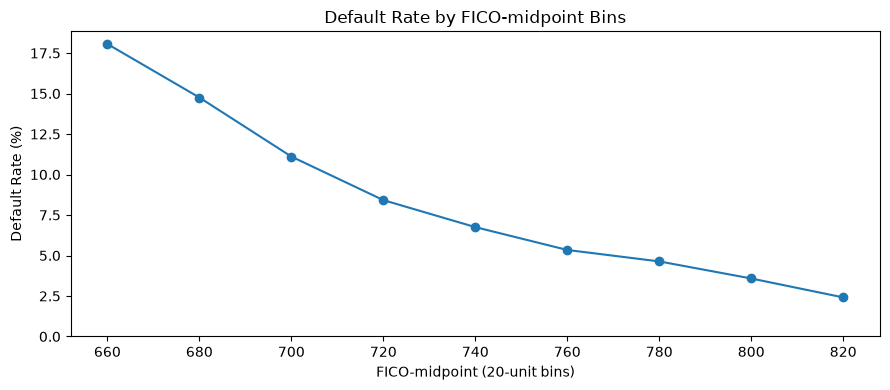

In [4]:
d_ficobins = q("""SELECT floor(((fico_range_low+fico_range_high)/2)/20)*20 AS fico_bin,
                avg(default_flag)*100 AS default_pct, count(*) AS n
         FROM cohort GROUP BY 1 HAVING count(*) > 500 ORDER BY 1""")
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(d_ficobins["fico_bin"], d_ficobins["default_pct"], marker="o")
ax.set_ylim(0)
ax.set_ylabel("Default Rate (%)"); ax.set_xlabel("FICO-midpoint (20-unit bins)"); ax.set_title("Default Rate by FICO-midpoint Bins")
fig.tight_layout()
fig.savefig(FIG/"default_rate_by_fico_bin.png", dpi=150, bbox_inches="tight")

Default rate falls monotonically with FICO, from ~18% at the 660 bin to ~2.5% at 820. ~7× gradient. The relationship is convex: steepest risk reduction is between 660 and 720, somewhat flattening above 760. A linear FICO term in the logistic model will understate risk at the low end and overstate it at the high end; LightGBM captures the curvature natively and the logistic's calibration curve should be checked for this shape.

Default rate by dti bin:

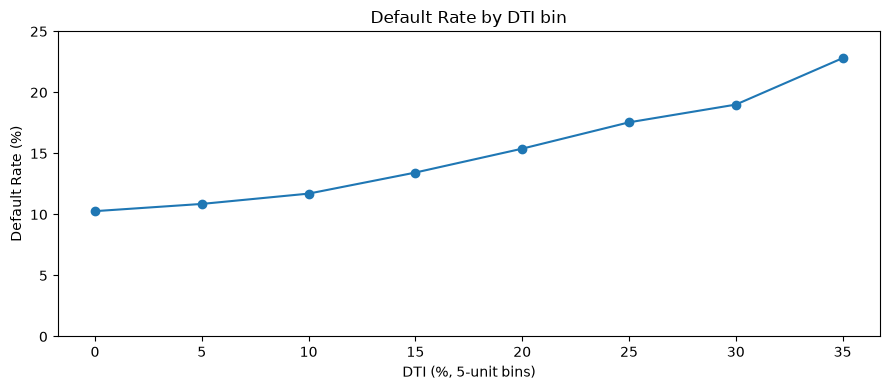

In [6]:
d_dti = q("""SELECT floor(dti/5)*5 AS dti_bin,
                    avg(default_flag)*100 AS default_pct, count(*) AS n
             FROM cohort
             WHERE dti IS NOT NULL
             GROUP BY 1 HAVING count(*) > 500 ORDER BY 1""")
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(d_dti["dti_bin"], d_dti["default_pct"], marker="o")
ax.set_ylim(0,25)
ax.set_ylabel("Default Rate (%)"); ax.set_xlabel("DTI (%, 5-unit bins)"); ax.set_title("Default Rate by DTI bin")
fig.tight_layout()
fig.savefig(FIG/"default_rate_by_dti.png", dpi=150, bbox_inches="tight")

Default rate rises monotonically with DTI roughly doubling from 10% (lowest bin) to 23% (35+). dti is well-behaved for both model classes; note DTI here excludes the mortgage/rent obligation (LendingClub's definition) so it understates total obligations for renters and mortgage-holders alike.

Interest rate vs realised default rate by sub-grade:

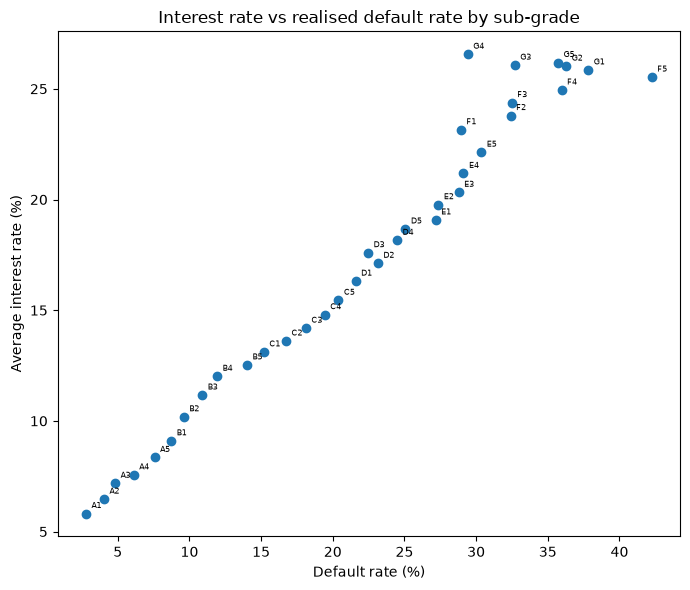

In [ ]:
#Interest rate vs realised default rate by sub-grade:
d_rate = q("""SELECT sub_grade, avg(int_rate) AS avg_int_rate,
                     avg(default_flag)*100 AS default_pct, count(*) AS n
              FROM cohort GROUP BY 1 ORDER BY 1""")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(d_rate["default_pct"], d_rate["avg_int_rate"])

for _, row in d_rate.iterrows():
    ax.annotate(row["sub_grade"], (row["default_pct"], row["avg_int_rate"]),
                textcoords="offset points", xytext=(4, 4), fontsize=6)
    
ax.set_xlabel("Default rate (%)")
ax.set_ylabel("Average interest rate (%)")
ax.set_title("Interest rate vs realised default rate by sub-grade")
fig.tight_layout()
fig.savefig(FIG/"rate_vs_default_by_subgrade.png", dpi=150, bbox_inches="tight")

Pricing tracks realised risk almost linearly through grade E; above it rates saturate near a ~26% ceiling while defaults climb to 42% suggesting the riskiest 36-month loans were not proportionally compensated (tail cells thin; individual F/G points noisy).

Missingness by origination year:

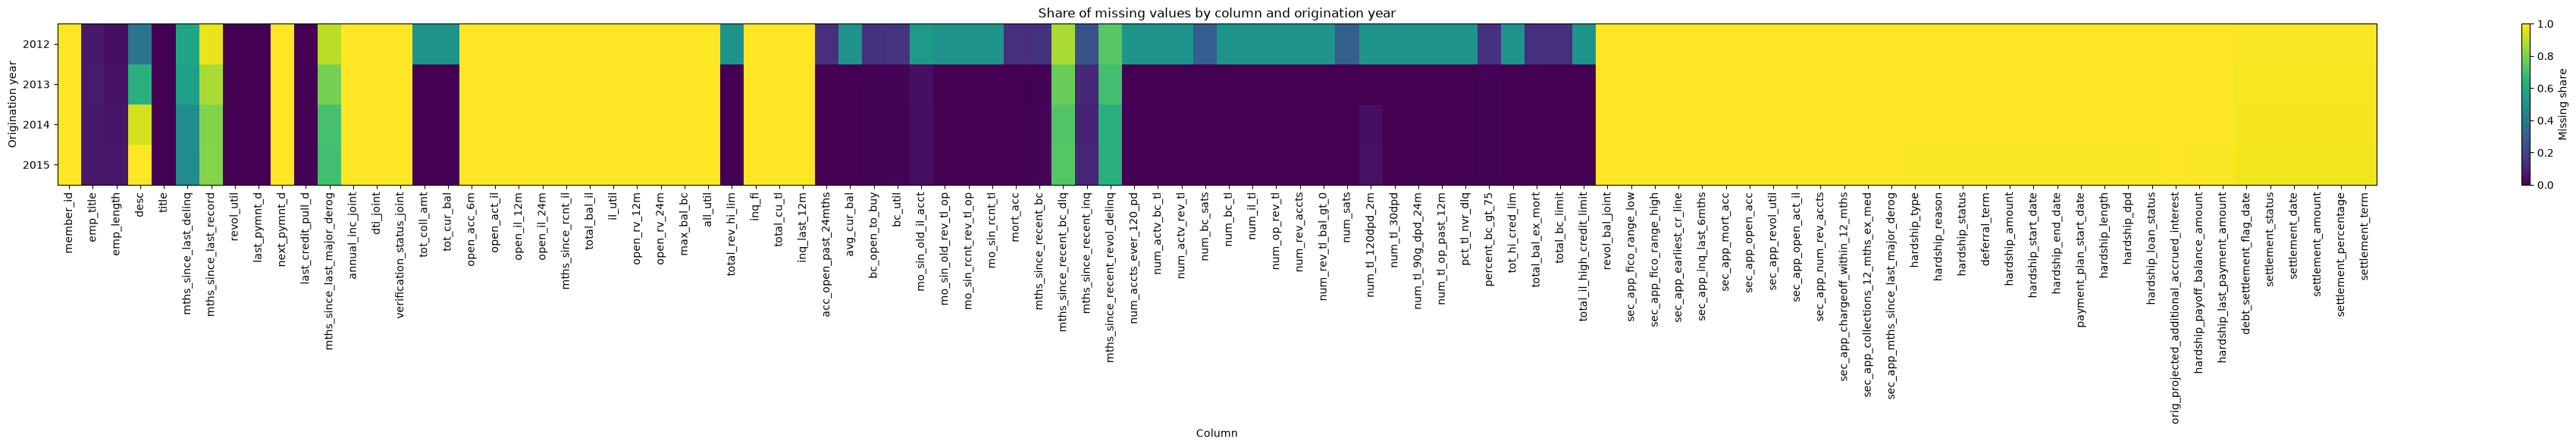

In [ ]:

import pandas as pd


df = q("SELECT * FROM cohort")
df["issue_date"] = pd.to_datetime(df["issue_date"])

miss_by_year = df.groupby(df["issue_date"].dt.year).apply(lambda g: g.isna().mean())

# restrict to columns with any missingness across the whole period
cols_with_missing = miss_by_year.columns[(miss_by_year > 0).any(axis=0)]
miss_by_year = miss_by_year[cols_with_missing]

fig, ax = plt.subplots(figsize=(max(8, len(cols_with_missing) * 0.4), 6))
im = ax.imshow(miss_by_year.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)

ax.set_yticks(range(len(miss_by_year.index)))
ax.set_yticklabels(miss_by_year.index)
ax.set_xticks(range(len(cols_with_missing)))
ax.set_xticklabels(cols_with_missing, rotation=90)
ax.set_xlabel("Column")
ax.set_ylabel("Origination year")
ax.set_title("Share of missing values by column and origination year")

fig.colorbar(im, ax=ax, label="Missing share")
fig.tight_layout()
fig.savefig(FIG/"missingness_by_year.png", dpi=150, bbox_inches="tight")

Missingness in three mechanisms: fields absent from this data release entirely; an expanded bureau block collected only from 2013 (motivating restriction of model features to all-vintage columns, since vintage-correlated missingness would confound the temporal split); and event-dependent fields where NaN means 'never occurred', requiring indicator-based rather than naive imputation.

Missingness by origination year (audited columns only):

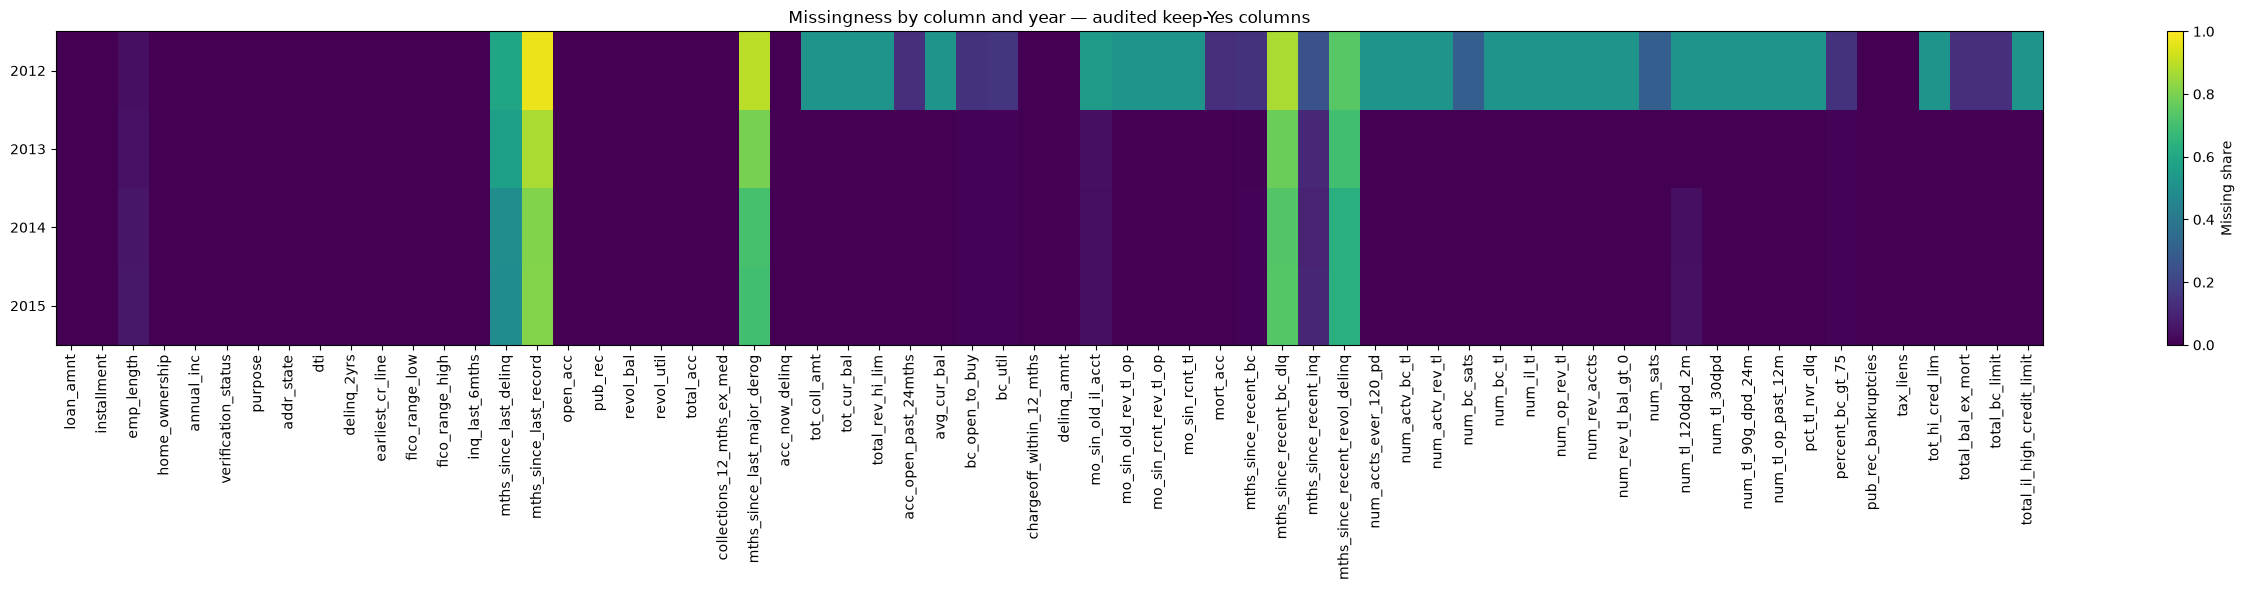

In [ ]:
audit = pd.read_csv("../reports/leakage_audit.csv") 

keep_cols = audit.loc[audit["keep"] == "Yes", "column_name"].tolist()

df_filtered = df[[c for c in keep_cols if c in df.columns]]
miss_by_year = df.groupby(df["issue_date"].dt.year).apply(
    lambda g: g.drop(columns="issue_date", errors="ignore").isna().mean())
miss_by_year = miss_by_year[[c for c in keep_cols if c in miss_by_year.columns]]

fig, ax = plt.subplots(figsize=(max(8, len(miss_by_year.columns) * 0.4), 6))
im = ax.imshow(miss_by_year.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_yticks(range(len(miss_by_year.index))); ax.set_yticklabels(miss_by_year.index)
ax.set_xticks(range(len(miss_by_year.columns))); ax.set_xticklabels(miss_by_year.columns, rotation=90)
ax.set_title("Missingness by column and year — audited keep-Yes columns")
fig.colorbar(im, ax=ax, label="Missing share")
fig.tight_layout()
fig.savefig(FIG/"missingness_by_year_audited.png", dpi=150, bbox_inches="tight")

Strong pairwise correlation for later steps: logistic coefficients become unstable and individually uninterpretable when predictors are collinear and SHAP values spread credit across correlated features in ways that need caveating.

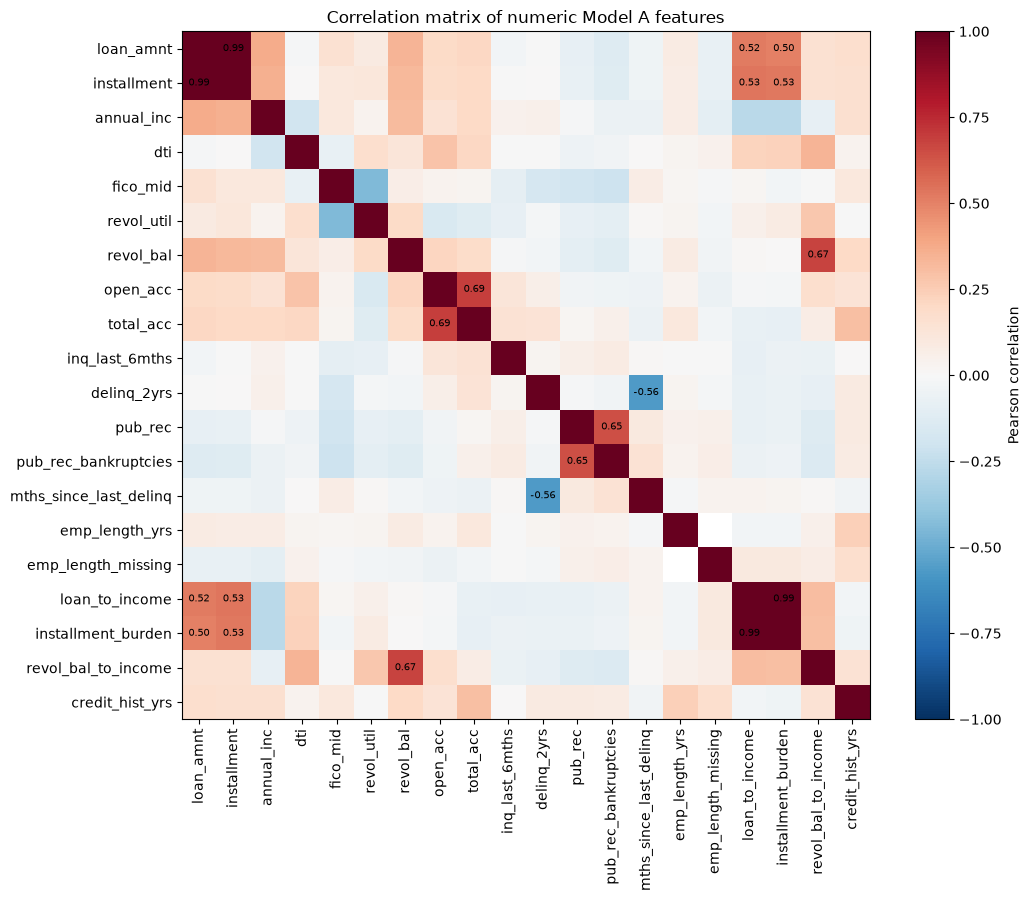

In [3]:

import pandas as pd
from lending_pd.features import engineer_features
from lending_pd.config import MODEL_A_FEATURES

df7 = engineer_features(con.execute("SELECT * FROM cohort").df())

num_feats = [f for f in MODEL_A_FEATURES
             if f in df7.columns and pd.api.types.is_numeric_dtype(df7[f])]
corr = df7[num_feats].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_feats)), num_feats, rotation=90)
ax.set_yticks(range(len(num_feats)), num_feats)
for i in range(len(num_feats)):
    for j in range(len(num_feats)):
        v = corr.iloc[i, j]
        if i != j and abs(v) >= 0.5:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, label="Pearson correlation")
ax.set_title("Correlation matrix of numeric Model A features")
fig.tight_layout()
fig.savefig(FIG / "feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

Two pairs were near-duplicates at r = 0.99; in both, the residual variation is interest rate (installment is deterministic in amount and rate at fixed term), so installment and installment_burden are excluded from Model A to keep the borrower-attributes/platform-pricing separation clean. Remaining moderate correlations (0.6–0.7) are retained with the caveat that logistic coefficients and SHAP attributions must be read jointly across correlated clusters.

Final Model A variable correlation matrix with near-duplicates (installment and installment_burden) excluded:

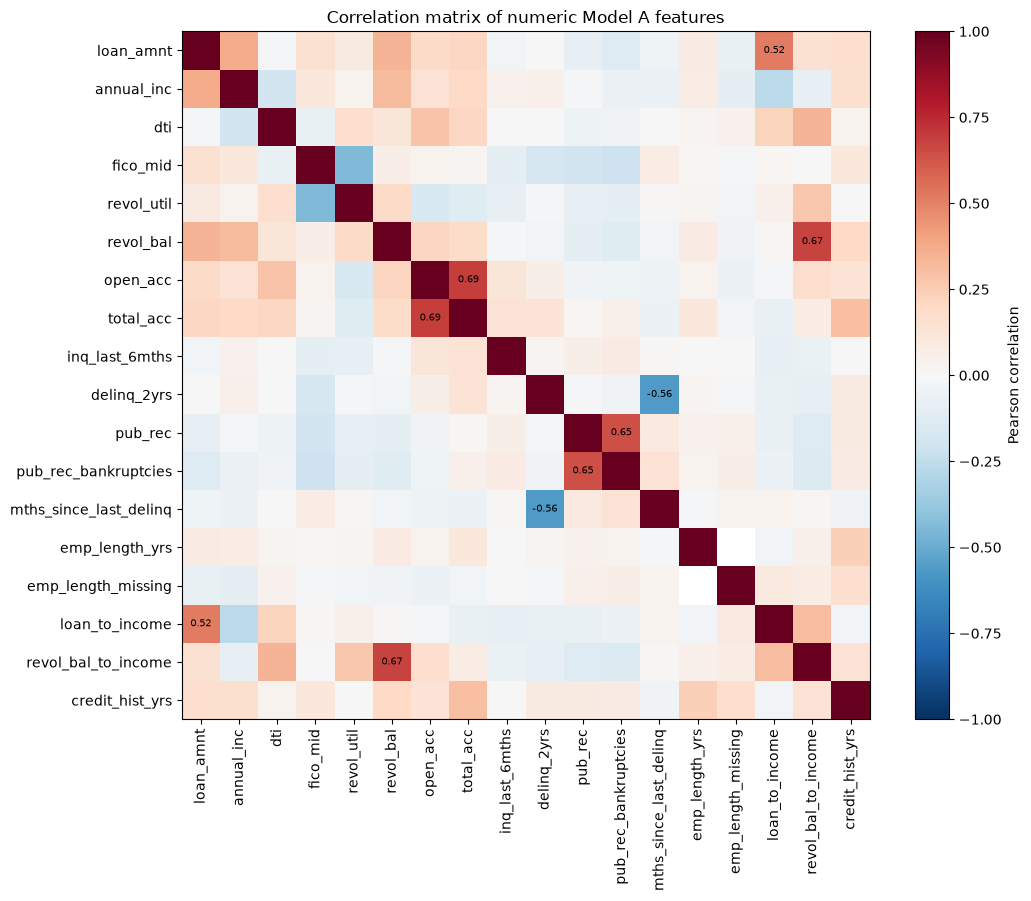

In [3]:
import pandas as pd
from lending_pd.features import engineer_features
from lending_pd.config import MODEL_A_FEATURES

df7 = engineer_features(con.execute("SELECT * FROM cohort").df())

num_feats = [f for f in MODEL_A_FEATURES
             if f in df7.columns and pd.api.types.is_numeric_dtype(df7[f])]
corr = df7[num_feats].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_feats)), num_feats, rotation=90)
ax.set_yticks(range(len(num_feats)), num_feats)
for i in range(len(num_feats)):
    for j in range(len(num_feats)):
        v = corr.iloc[i, j]
        if i != j and abs(v) >= 0.5:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, label="Pearson correlation")
ax.set_title("Correlation matrix of numeric Model A features")
fig.tight_layout()
fig.savefig(FIG / "feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

open_acc/total_acc at 0.69, pub_rec/pub_rec_bankruptcies at 0.65, revol_bal/revol_bal_to_income at 0.67. The delinq_2yrs vs mths_since_last_delinq cell at −0.56 . fico_mid vs revol_util shows the expected negative shading below the annotation threshold. These moderate correlations (0.6–0.7) are retained with the caveat that logistic coefficients and SHAP attributions must be read jointly across correlated clusters.